In [94]:
import pandas as pd
import matplotlib.pyplot as plt
from wordcloud import WordCloud

In [95]:
df=pd.read_csv('Reviews.csv')
df.head()

,Id,ProductId,UserId,ProfileName,HelpfulnessNumerator,HelpfulnessDenominator,Score,Time,Summary,Text
0,1,B001E4KFG0,A3SGXH7AUHU8GW,delmartian,1,1,5,1303862400,Good Quality Dog Food,I have bought several of the Vitality canned d...
1,2,B00813GRG4,A1D87F6ZCVE5NK,dll pa,0,0,1,1346976000,Not as Advertised,Product arrived labeled as Jumbo Salted Peanut...
2,3,B000LQOCH0,ABXLMWJIXXAIN,"Natalia Corres ""Natalia Corres""",1,1,4,1219017600,"""Delight"" says it all",This is a confection that has been around a fe...
3,4,B000UA0QIQ,A395BORC6FGVXV,Karl,3,3,2,1307923200,Cough Medicine,If you are looking for the secret ingredient i...
4,5,B006K2ZZ7K,A1UQRSCLF8GW1T,"Michael D. Bigham ""M. Wassir""",0,0,5,1350777600,Great taffy,Great taffy at a great price. There was a wid...


In [96]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 568454 entries, 0 to 568453
Data columns (total 10 columns):
 #   Column                  Non-Null Count   Dtype 
---  ------                  --------------   ----- 
 0   Id                      568454 non-null  int64 
 1   ProductId               568454 non-null  object
 2   UserId                  568454 non-null  object
 3   ProfileName             568428 non-null  object
 4   HelpfulnessNumerator    568454 non-null  int64 
 5   HelpfulnessDenominator  568454 non-null  int64 
 6   Score                   568454 non-null  int64 
 7   Time                    568454 non-null  int64 
 8   Summary                 568427 non-null  object
 9   Text                    568454 non-null  object
dtypes: int64(5), object(5)
memory usage: 43.4+ MB


In [97]:
df.isnull().sum()

Id                         0
ProductId                  0
UserId                     0
ProfileName               26
HelpfulnessNumerator       0
HelpfulnessDenominator     0
Score                      0
Time                       0
Summary                   27
Text                       0
dtype: int64

In [98]:
cols_to_drop=['Id','UserId','ProfileName','Time']
df=df.drop(columns=cols_to_drop)

In [99]:
df.columns.tolist()

['ProductId',
 'HelpfulnessNumerator',
 'HelpfulnessDenominator',
 'Score',
 'Summary',
 'Text']

In [100]:
df=df.drop(columns='Summary')

In [101]:
df.describe()

,HelpfulnessNumerator,HelpfulnessDenominator,Score
count,568454.000000,568454.00000,568454.000000
mean,1.743817,2.22881,4.183199
std,7.636513,8.28974,1.310436
min,0.000000,0.00000,1.000000
25%,0.000000,0.00000,4.000000
50%,0.000000,1.00000,5.000000
75%,2.000000,2.00000,5.000000
max,866.000000,923.00000,5.000000


In [102]:
df.duplicated().sum()

np.int64(475)

In [103]:
df=df.drop_duplicates()

In [104]:
df['Score'].value_counts().sort_index()

Score
1     52228
2     29764
3     42597
4     80622
5    362768
Name: count, dtype: int64

**Insights:**
- The dataset is heavily positively skewed.
- Most customers were satisfied(5-Star reviews ~64%)
- Negative Reviews are a minority
- Any sentiment model trained on this data may become biased towards predicting positive sentiment.

#### 1. Rating Distribution Bar Chart

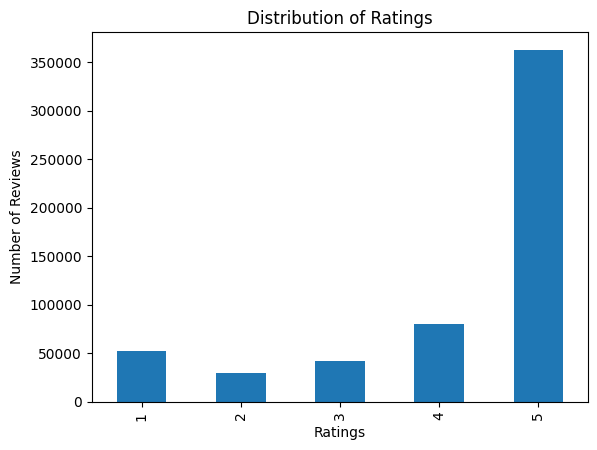

In [105]:
rating_counts=df['Score'].value_counts().sort_index()
rating_counts.plot(kind='bar')
plt.title("Distribution of Ratings")
plt.xlabel("Ratings")
plt.ylabel("Number of Reviews")
plt.show()

In [106]:
# Review Length Feature
df['Review_Length']=df['Text'].astype(str).apply(len)

In [107]:
df['Review_Length'].describe()

count    567979.000000
mean        435.636101
std         443.773394
min          12.000000
25%         179.000000
50%         301.000000
75%         527.000000
max       21409.000000
Name: Review_Length, dtype: float64

**Insights:**
- Mean is much higher than medium.
- Most reviews are relatively short.
- A small number of extremely long reviews are pulling the average upward

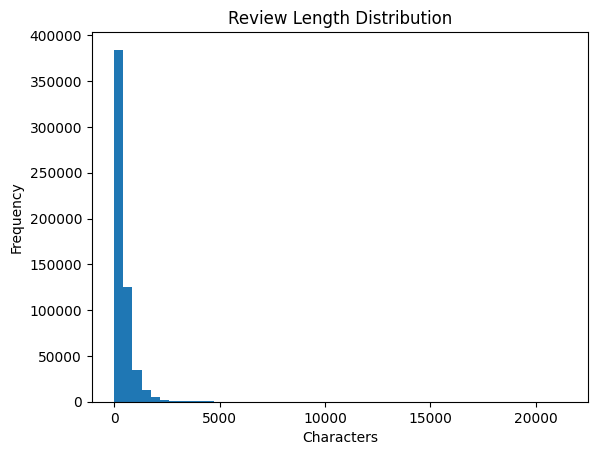

In [108]:
#Review Length Distribution
plt.hist(df['Review_Length'],bins=50)
plt.title("Review Length Distribution")
plt.xlabel('Characters')
plt.ylabel("Frequency")
plt.show()

In [109]:
avg_length=df.groupby('Score')['Review_Length'].mean()
avg_length

Score
1    476.637895
2    490.628679
3    519.772871
4    496.499219
5    401.815254
Name: Review_Length, dtype: float64

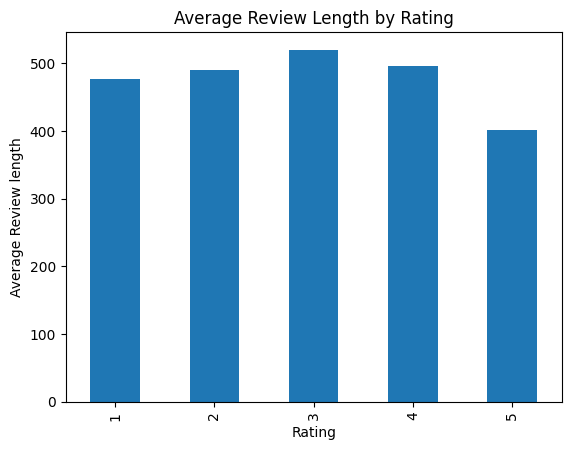

In [110]:
avg_length.plot(kind='bar')
plt.title("Average Review Length by Rating")
plt.xlabel("Rating")
plt.ylabel('Average Review length')
plt.show()

**Insight**
- The review length varies by rating.
- Five-star reviews are the shortest on average(402 characters)
- Three star reviews are the longest.
- This suggests higly satisfied customers tend to leave concise feedback, whereas customers with mixed experiences provide more detailed explanations.

### Rating-Based Sentiment Analysis

In [111]:
#Sentiment Labels
def sentiment_label(score):
    if score <=2:
        return "Negative"
    elif score ==3:
        return "Neutral"
    else:
        return "Positive"
    
df['Sentiment']=df['Score'].apply(sentiment_label)

In [112]:
df['Sentiment'].value_counts()

Sentiment
Positive    443390
Negative     81992
Neutral      42597
Name: count, dtype: int64

In [113]:
PositivePer=(443390/567979)*100
NegativePer=(81992/567979)*100
NeutralPer=(42597/567979)*100

print("Positive%:",PositivePer, "%")
print("Negative%:",NegativePer, "%")
print("Neutral%:",NeutralPer, "%")



Positive%: 78.06450590602822 %
Negative%: 14.43574498352932 %
Neutral%: 7.499749110442464 %


**Insight:**
- Nearly 4 out of every 5 reviews are positive.

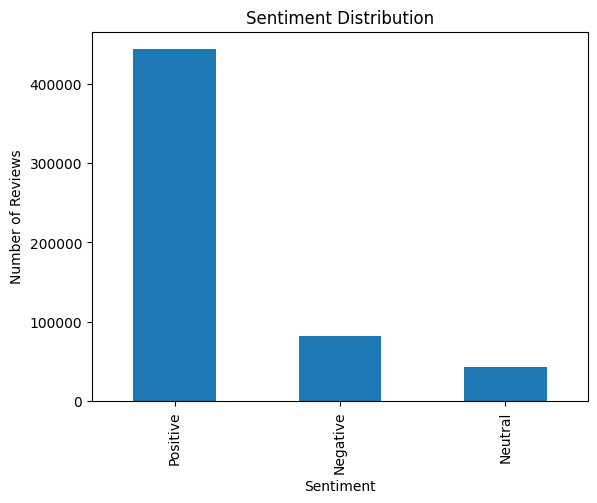

In [114]:
sentiment_counts=df['Sentiment'].value_counts()
sentiment_counts.plot(kind='bar')
plt.title("Sentiment Distribution")
plt.xlabel("Sentiment")
plt.ylabel("Number of Reviews")
plt.show()

### NLP Analysis

In [115]:
positive_reviews=df[df['Sentiment']=='Positive']

In [116]:
negative_reviews=df[df['Sentiment']=='Negative']

In [117]:
positive_sample=positive_reviews.sample(50000,random_state=42)
neagtive_sample=negative_reviews.sample(50000,random_state=42)

In [118]:
#Combine Review Text
positive_text=" ".join(positive_sample['Text'].astype(str))
negative_text=" ".join(neagtive_sample['Text'].astype(str))

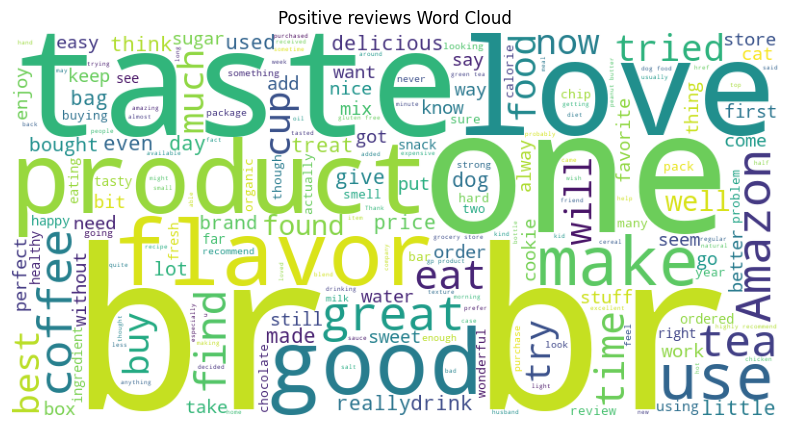

In [119]:
# Generate Word count
wordcloud_positive=WordCloud(
    width=800,
    height=400,
    background_color='white'
).generate(positive_text)

plt.figure(figsize=(10,5))
plt.imshow(wordcloud_positive)
plt.axis('off')
plt.title('Positive reviews Word Cloud')
plt.show()

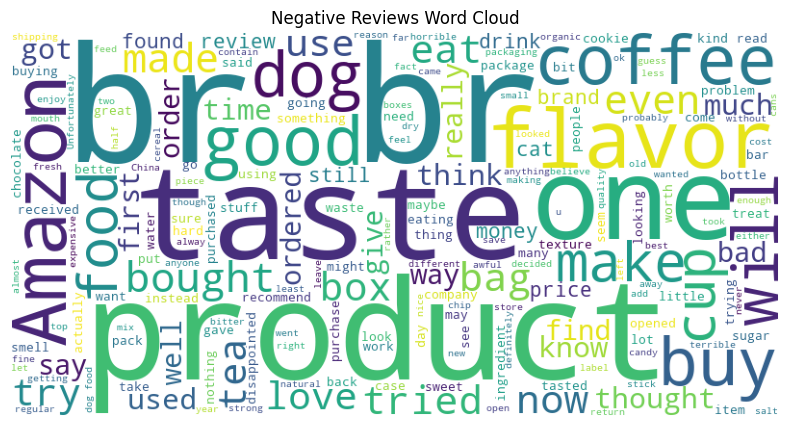

In [120]:
wordcloud_negative=WordCloud(
    width=800,
    height=400,
    background_color='white'
).generate(negative_text)

plt.figure(figsize=(10,5))
plt.imshow(wordcloud_negative)
plt.title("Negative Reviews Word Cloud")
plt.axis('off')
plt.show()

In [121]:
from collections import Counter
import re

In [122]:
positive_words=re.findall(r'\b[a-zA-Z]+\b',positive_text.lower())
positive_counts=Counter(positive_words)
print(positive_counts.most_common(20))

[('the', 152639), ('i', 140862), ('and', 114439), ('a', 107544), ('it', 89580), ('to', 85961), ('of', 66832), ('is', 64384), ('this', 57525), ('br', 54454), ('for', 48544), ('in', 47112), ('my', 41453), ('that', 36614), ('you', 32173), ('with', 30910), ('have', 30218), ('but', 29334), ('are', 28444), ('they', 26530)]


In [123]:
negative_words=re.findall(r'\b[a-zA-z]+\b',negative_text.lower())
negative_count=Counter(negative_words)
print(negative_count.most_common(20))

[('the', 198681), ('i', 174900), ('and', 111446), ('it', 102408), ('a', 102153), ('to', 98758), ('of', 81685), ('this', 69561), ('br', 63696), ('is', 61331), ('in', 51242), ('that', 48617), ('not', 47580), ('was', 46776), ('for', 45328), ('but', 39881), ('my', 37957), ('t', 35947), ('they', 30861), ('have', 30592)]


In [124]:
import nltk
nltk.download('stopwords')

[nltk_data] Downloading package stopwords to C:\Users\JANWI
[nltk_data]     KUMARI\AppData\Roaming\nltk_data...
[nltk_data]   Package stopwords is already up-to-date!


True

In [125]:
from nltk.corpus import stopwords
stop_words= set(stopwords.words('english'))

In [126]:
positive_words=re.findall(r'\b[a-zA-Z]+\b',positive_text.lower())

positive_words=[
    word for word in positive_words
    if word not in stop_words and len(word)>2 and word!='br'
]

In [127]:
negative_words=re.findall(r'\b[a-zA-Z]+\b',negative_text.lower())

negative_words=[
    word for word in negative_words
    if word not in stop_words and len(word)>2 and word!='br'
]

In [128]:
positive_counts=Counter(positive_words)
print(positive_counts.most_common(20))

[('like', 20490), ('good', 18114), ('great', 16913), ('one', 15011), ('coffee', 14138), ('taste', 13859), ('product', 13214), ('tea', 12874), ('love', 12589), ('flavor', 12492), ('food', 10937), ('amazon', 9322), ('get', 9192), ('would', 9134), ('really', 8664), ('also', 7992), ('best', 7815), ('much', 7782), ('use', 7713), ('time', 7567)]


In [129]:
negative_count=Counter(negative_words)
print(negative_count.most_common(20))

[('like', 27316), ('product', 21419), ('taste', 19677), ('one', 17117), ('would', 16381), ('food', 14048), ('coffee', 13771), ('good', 13293), ('flavor', 12649), ('amazon', 10260), ('even', 10047), ('tea', 10034), ('get', 9804), ('buy', 9171), ('really', 8832), ('much', 8696), ('tried', 7324), ('first', 7301), ('box', 7292), ('dog', 7290)]


**Insight:**
Several frequently occurring words such as "coffee","taste","product" and "flavor" appeared in both positive and negative reviews. This indicates that frequency alone does not determine sentiment and thta context plays an important role in understanding customer opinions.

In [130]:
custom_words=[
    'product',
    'products',
    'amazon',
    'coffee',
    'tea',
    'food',
    'taste',
    'flavor',
    'one',
    'would',
    'get',
    'really',
    'also',
    'much'
]

In [131]:
positive_words=[
    word for word in positive_words
    if word not in custom_words
]

In [135]:
negative_words=[
    word for word in negative_words
    if word not in custom_words
]

In [136]:
from collections import Counter
positive_counts=Counter(positive_words)
print(positive_counts.most_common(20))

[('like', 20490), ('good', 18114), ('great', 16913), ('love', 12589), ('best', 7815), ('use', 7713), ('time', 7567), ('little', 7351), ('price', 7046), ('find', 6864), ('tried', 6753), ('well', 6626), ('make', 6393), ('buy', 6311), ('even', 5902), ('eat', 5826), ('try', 5806), ('dog', 5753), ('better', 5749), ('cup', 5470)]


In [137]:
negative_count=Counter(negative_words)
print(negative_count.most_common(20))

[('like', 27316), ('good', 13293), ('even', 10047), ('buy', 9171), ('tried', 7324), ('first', 7301), ('box', 7292), ('dog', 7290), ('time', 7008), ('bought', 6832), ('eat', 6542), ('made', 6517), ('bad', 6493), ('better', 6354), ('try', 6261), ('bag', 6139), ('water', 5985), ('got', 5884), ('could', 5790), ('great', 5575)]


**Insight:**
Negative reviews often focus on product usage experiences, purchasing decisions, packaging, and specific product-related concerns.

### TextBlob Sentiment Analysis


In [138]:
from textblob import TextBlob

In [139]:
sample_df=df.sample(10000,random_state=42)
sample_df['Polarity']=sample_df['Text'].apply(lambda x: TextBlob(str(x)).sentiment.polarity)

In [140]:
def classify_sentiment(score):
    if score>0:
        return "Positive"
    elif score <0:
        return "Negative"
    else:
        return "Neutral"
    
sample_df['NLP_Sentiment']=sample_df['Polarity'].apply(classify_sentiment)

In [141]:
sample_df['NLP_Sentiment'].value_counts()

NLP_Sentiment
Positive    8801
Negative    1040
Neutral      159
Name: count, dtype: int64

In [143]:
pd.crosstab(sample_df['Score'],sample_df['NLP_Sentiment'])

NLP_Sentiment,Negative,Neutral,Positive
Score,,,
1,436,42,495
2,137,14,363
3,93,15,638
4,87,15,1293
5,287,73,6012


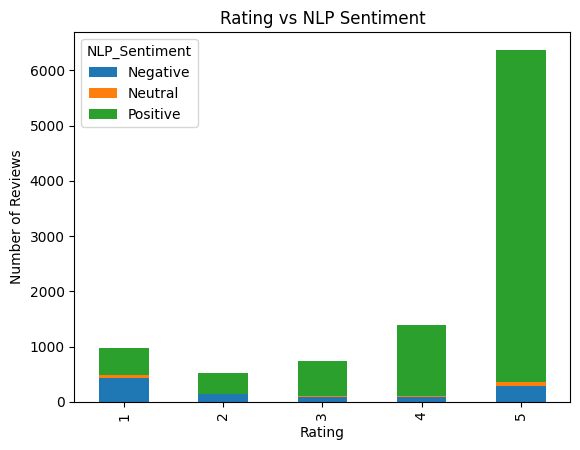

In [144]:
pd.crosstab(sample_df['Score'],sample_df['NLP_Sentiment']).plot(kind='bar',stacked='True')
plt.title('Rating vs NLP Sentiment')
plt.xlabel('Rating')
plt.ylabel('Number of Reviews')
plt.show()

**Insight:**
The comaprison between rating-based sentiment and TextBlob sentiment revealed notable differences. Many low-rated reviews conatined positive words, causing the NLP model to classify them as positive despite the negative rating. This highlights the limitation of lexicon- based sentiment analysis and the importance of contextual understanding.

## Key Findings
1. Positive sentiment dominated the dataset, accounting for approximately 78% of all reviews.
2. Five-Star reviews represented the largest share of customer feedback.
3. Three-star reviews were the longest on average, suggesting customers provide more detailed feedback when they have mixed experiences.
4. Common posiitve words include "good","great","love","most".
5. Comparison between rating-based and NLP-based sentiment showed that lexicon-based models may misclassify some reviews due to context limitations.
6. TextBlob aligned more accurately with higly positive reviews than with highly neagtive reviews.

## Recommendations
1. Continue maintaining product quality to sustain high customer satisfaction.
2. Analyze negative reviews to identify recurring customer concerns.
3. Pay special attention to deatiled three- star reviews as they often contain balanced feedback and improvement suggestions.
4. Use advanced sentiment models in future studies for better contextual understanding of customer opinions.

## Conclusions:
This project analyzed over 568000 Amazon customer reviews using data analytics and sentiment analysis techniques. The analysis revealed a strong positive sentiment across customers and highlighted differences between rating-based and NLP-based sentiment classification. The findings provide valuable insights into customer behaviour, review patterns and product perception.